# Model Training & Comparative Analysis

In questo notebook addestreremo 4 diversi modelli di classificazione sul dataset processato e li valuteremo sul **GUIDE Test Set**. 

**Obiettivo:** Identificare il modello migliore per predire se un incidente è un **True Positive** (Minaccia Reale).

**Modelli:**
1.  **Decision Tree**: Modello baseline interpretabile.
2.  **Random Forest**: Modello ensemble robusto.
3.  **XGBoost**: Gradient Boosting (spesso SOTA su dati tabulari).
4.  **Feed Forward Neural Network (MLP)**: Rete neurale multistrato.

**Strategia Anti-Leakage:**
*   Lo split Train/Validation è stato fatto **a monte** nel notebook di Feature Engineering (a livello IncidentId, PRIMA del Target Encoding).
*   `train_final_balanced.csv`: 80% degli incidenti (undersampled)
*   `val_final.csv`: 20% degli incidenti (distribuzione reale, NO leakage)
*   `test_final.csv`: GUIDE_Test (valutazione finale)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle

# Modelli
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

# Metriche e Utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

# Configurazioni
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_style('whitegrid')

# Percorsi
DATA_DIR = '../data/processed_final'

print("Librerie caricate.")

Librerie caricate.


## 1. Caricamento e Preparazione Dati

In [2]:
# Carichiamo i dataset generati dalla pipeline precedente (già splittati senza leakage)
print("Caricamento dati...")

train_df = pd.read_csv(os.path.join(DATA_DIR, 'train_final_balanced.csv'))
# IMPORTANTE: Usiamo il validation set SBILANCIATO per valutare le performance reali
# (vedi docs/methodology.md per la giustificazione)
val_df = pd.read_csv(os.path.join(DATA_DIR, 'val_final.csv'))  
test_df = pd.read_csv(os.path.join(DATA_DIR, 'test_final.csv'))

# Colonne da escludere
features_to_drop = ['IncidentId', 'Target']

# Train Set (90%, bilanciato tramite undersampling)
X_train = train_df.drop(columns=features_to_drop, errors='ignore')
y_train = train_df['Target']

# Validation Set (10%, distribuzione REALE - NO undersampling)
X_val = val_df.drop(columns=features_to_drop, errors='ignore')
y_val = val_df['Target']

# Test Set (GUIDE_Test ridotto a 20k incidenti bilanciati)
X_test_final = test_df.drop(columns=features_to_drop, errors='ignore')
y_test_final = test_df['Target']

# Rimuoviamo eventuali righe con Target NaN nel test set
valid_test_mask = y_test_final.notna()
X_test_final = X_test_final[valid_test_mask]
y_test_final = y_test_final[valid_test_mask]

print(f"Train Set (Balanced):  {X_train.shape}")
print(f"Validation Set (Real): {X_val.shape} - Distribuzione: {y_val.value_counts().to_dict()}")
print(f"Test Set (Hold-out):   {X_test_final.shape}")

Caricamento dati...
Train Set (Balanced):  (303212, 38)
Validation Set (Real): (33730, 38) - Distribuzione: {0: 16865, 1: 16865}
Test Set (Hold-out):   (20000, 38)


### 1.1 Scaling
Le reti neurali richiedono dati scalati. Gli alberi non ne hanno bisogno, ma non ne soffrono. Scaliamo tutto per uniformità.

**Nota:** Lo split Train/Validation è già stato eseguito nel notebook di Feature Engineering per evitare data leakage nel Target Encoding.

In [3]:
# Scaling (fit su train, transform su val e test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test_final)

print("Dati scalati.")
print(f"Train samples: {X_train.shape[0]}")
print(f"Val samples:   {X_val.shape[0]}")
print(f"Test samples:  {X_test_final.shape[0]}")

Dati scalati.
Train samples: 303212
Val samples:   33730
Test samples:  20000


## 2. Hyperparameter Tuning con Cross-Validation

Prima di addestrare i modelli finali, eseguiamo una ricerca degli iperparametri ottimali usando **RandomizedSearchCV** con 5-fold stratified cross-validation.

**Perché RandomizedSearchCV?**
- Più efficiente di GridSearchCV su spazi ampi
- Permette di fissare un budget computazionale (n_iter)
- Esplora combinazioni diverse ad ogni run

> Vedi `docs/methodology.md` per dettagli sulle scelte metodologiche.

In [4]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform

# Cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Decision Tree Tuning ---
print("Tuning Decision Tree...")
dt_param_dist = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8]
}
dt_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_dist, n_iter=20, cv=cv, scoring='f1', n_jobs=-1, random_state=42
)
dt_search.fit(X_train, y_train)
print(f"Best DT params: {dt_search.best_params_}")
print(f"Best DT CV F1: {dt_search.best_score_:.4f}")

# --- Random Forest Tuning ---
print("\nTuning Random Forest...")
rf_param_dist = {
    'n_estimators': [50, 100, 150],      # Ridotto da 200
    'max_depth': [10, 15, 20],           # Rimosso None (molto lento)
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(n_jobs=1, random_state=42),  # n_jobs=1 qui
    rf_param_dist, n_iter=15, cv=cv, scoring='f1', 
    n_jobs=-1,  # Parallelizza solo CV, non ogni RF
    random_state=42,
    verbose=1   # Mostra progresso
)
rf_search.fit(X_train, y_train)
print(f"Best RF params: {rf_search.best_params_}")
print(f"Best RF CV F1: {rf_search.best_score_:.4f}")

# --- XGBoost Tuning ---
print("\nTuning XGBoost...")
xgb_param_dist = {
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss', n_jobs=-1, random_state=42),
    xgb_param_dist, n_iter=30, cv=cv, scoring='f1', n_jobs=-1, random_state=42
)
xgb_search.fit(X_train, y_train)
print(f"Best XGB params: {xgb_search.best_params_}")
print(f"Best XGB CV F1: {xgb_search.best_score_:.4f}")

# Salviamo i migliori iperparametri
best_params = {
    'DecisionTree': dt_search.best_params_,
    'RandomForest': rf_search.best_params_,
    'XGBoost': xgb_search.best_params_
}
print("\n✅ Hyperparameter tuning completato!")

Tuning Decision Tree...
Best DT params: {'min_samples_split': 20, 'min_samples_leaf': 1, 'max_depth': 15}
Best DT CV F1: 0.8517

Tuning Random Forest...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best RF params: {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 20}
Best RF CV F1: 0.8620

Tuning XGBoost...
Best XGB params: {'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
Best XGB CV F1: 0.8679

✅ Hyperparameter tuning completato!


## 3. Addestramento Modelli con Parametri Ottimali

Addestriamo i modelli usando i migliori iperparametri trovati dalla cross-validation.

In [ ]:
# Dizionario per salvare i modelli addestrati e i risultati
models = {}
results = {}

# Nota: I modelli sono stati addestrati tramite RandomizedSearchCV nella sezione 2
# e poi riutilizzati tramite best_estimator_

### 3.1 Decision Tree

In [6]:
# Utilizziamo i best_estimator già addestrati dalla cross-validation
models['DecisionTree'] = dt_search.best_estimator_

# Validazione su validation set (distribuzione reale)
dt_preds = models['DecisionTree'].predict(X_val)
dt_probs = models['DecisionTree'].predict_proba(X_val)[:, 1]
print(f"DecisionTree - Validation F1: {f1_score(y_val, dt_preds):.4f}")
print(f"DecisionTree - Validation AUC: {roc_auc_score(y_val, dt_probs):.4f}")
print(f"Params: {dt_search.best_params_}")

DecisionTree - Validation F1: 0.8299
DecisionTree - Validation AUC: 0.9123
Params: {'min_samples_split': 20, 'min_samples_leaf': 1, 'max_depth': 15}


### 3.2 Random Forest

In [7]:
# Utilizziamo i best_estimator già addestrati dalla cross-validation
models['RandomForest'] = rf_search.best_estimator_

# Validazione su validation set (distribuzione reale)
rf_preds = models['RandomForest'].predict(X_val)
rf_probs = models['RandomForest'].predict_proba(X_val)[:, 1]
print(f"RandomForest - Validation F1: {f1_score(y_val, rf_preds):.4f}")
print(f"RandomForest - Validation AUC: {roc_auc_score(y_val, rf_probs):.4f}")
print(f"Params: {rf_search.best_params_}")

RandomForest - Validation F1: 0.8391
RandomForest - Validation AUC: 0.9291
Params: {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 20}


### 3.3 XGBoost

In [8]:
# Utilizziamo i best_estimator già addestrati dalla cross-validation
models['XGBoost'] = xgb_search.best_estimator_

# Validazione su validation set (distribuzione reale)
xgb_preds = models['XGBoost'].predict(X_val)
xgb_probs = models['XGBoost'].predict_proba(X_val)[:, 1]
print(f"XGBoost - Validation F1: {f1_score(y_val, xgb_preds):.4f}")
print(f"XGBoost - Validation AUC: {roc_auc_score(y_val, xgb_probs):.4f}")
print(f"Params: {xgb_search.best_params_}")

XGBoost - Validation F1: 0.8468
XGBoost - Validation AUC: 0.9338
Params: {'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 0.9}


### 3.4 Feed Forward Neural Network (MLP - Sklearn)

Per MLP non usiamo RandomizedSearchCV ma l'early stopping integrato in MLPClassifier.

In [9]:
# MLP con Sklearn - usa early stopping integrato
# Non facciamo tuning esaustivo per MLP sklearn, usiamo parametri ragionevoli
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64), 
    activation='relu', 
    solver='adam', 
    alpha=0.001,  # Regolarizzazione L2
    batch_size=256,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=200,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10
)

print("Addestramento MLP (Sklearn)...")
mlp_model.fit(X_train_scaled, y_train)
models['MLP'] = mlp_model

# Validazione
mlp_preds = mlp_model.predict(X_val_scaled)
mlp_probs = mlp_model.predict_proba(X_val_scaled)[:, 1]
print(f"MLP - Validation F1: {f1_score(y_val, mlp_preds):.4f}")
print(f"MLP - Validation AUC: {roc_auc_score(y_val, mlp_probs):.4f}")
print(f"MLP - Epochs completed: {mlp_model.n_iter_}")

Addestramento MLP (Sklearn)...
MLP - Validation F1: 0.8107
MLP - Validation AUC: 0.9023
MLP - Epochs completed: 26


## 4. Valutazione Finale su GUIDE_Test

Ora testiamo i modelli sul dataset di test reale (`GUIDE_Test`), che non hanno mai visto.

In [10]:
final_metrics = []

print("Valutazione sul Test Set Finale (GUIDE_Test)...")

for name, model in models.items():
    # Scegli il dataset corretto (scalato per MLP, normale per altri)
    X_target = X_test_scaled if name == 'MLP' else X_test_final
    
    # Predizioni
    y_pred = model.predict(X_target)
    y_prob = model.predict_proba(X_target)[:, 1]
    
    # Calcolo Metriche
    acc = accuracy_score(y_test_final, y_pred)
    prec = precision_score(y_test_final, y_pred)
    rec = recall_score(y_test_final, y_pred)
    f1 = f1_score(y_test_final, y_pred)
    auc = roc_auc_score(y_test_final, y_prob)
    
    final_metrics.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC': auc
    })
    
    # Salva predizioni per analisi successive
    results[name] = {'y_pred': y_pred, 'y_prob': y_prob}

# Tabella Comparativa
metrics_df = pd.DataFrame(final_metrics).set_index('Model')
print("\n--- Risultati Finali ---")
display(metrics_df.style.background_gradient(cmap='viridis', axis=0))

Valutazione sul Test Set Finale (GUIDE_Test)...

--- Risultati Finali ---


,Accuracy,Precision,Recall,F1-Score,AUC
Model,,,,,
DecisionTree,0.786800,0.807658,0.781929,0.794585,0.885370
RandomForest,0.791900,0.825201,0.768086,0.795620,0.899208
XGBoost,0.801850,0.827432,0.788755,0.807631,0.906128
MLP,0.767850,0.810149,0.731108,0.768602,0.872016


## 5. Visualizzazioni e Confronto

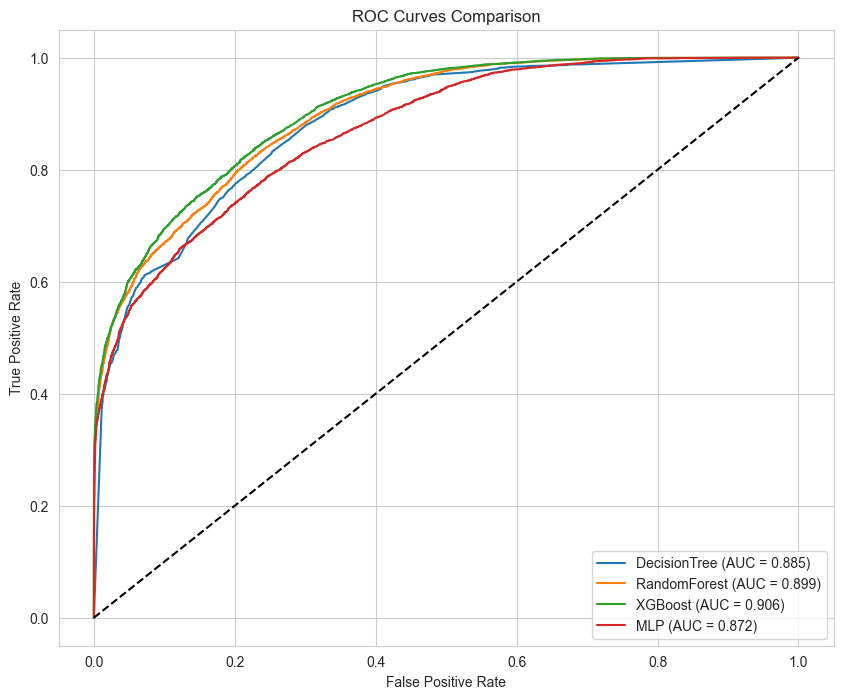

In [11]:
# 1. ROC Curves
plt.figure(figsize=(10, 8))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test_final, res['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test_final, res['y_prob']):.3f})")

plt.plot([0, 1], [0, 1], 'k--', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.show()

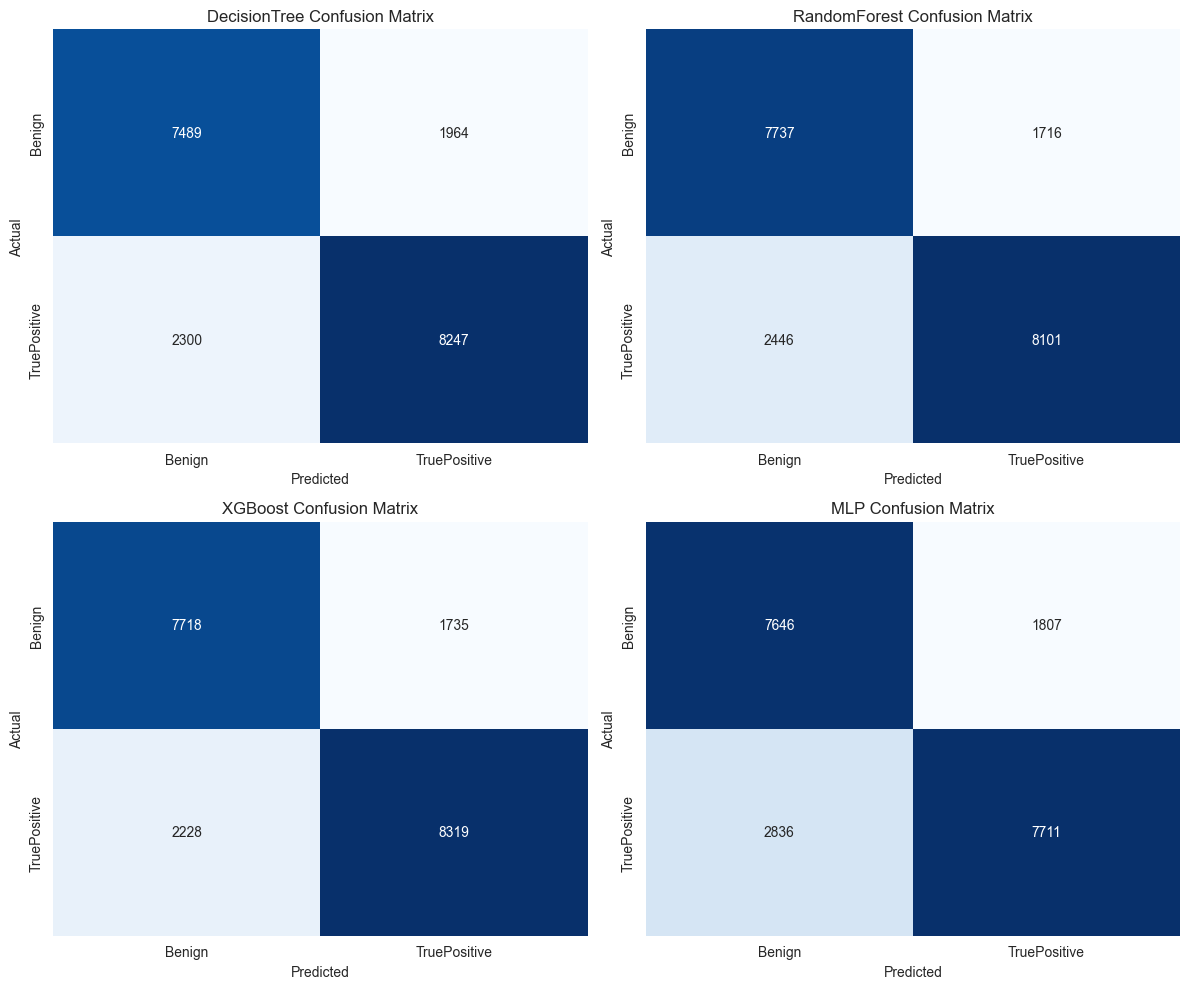

In [12]:
# 2. Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test_final, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
    axes[i].set_xticklabels(['Benign', 'TruePositive'])
    axes[i].set_yticklabels(['Benign', 'TruePositive'])

plt.tight_layout()
plt.show()

## 6. Feature Importance (XGBoost)

Vediamo quali feature sono state più determinanti per il modello migliore.

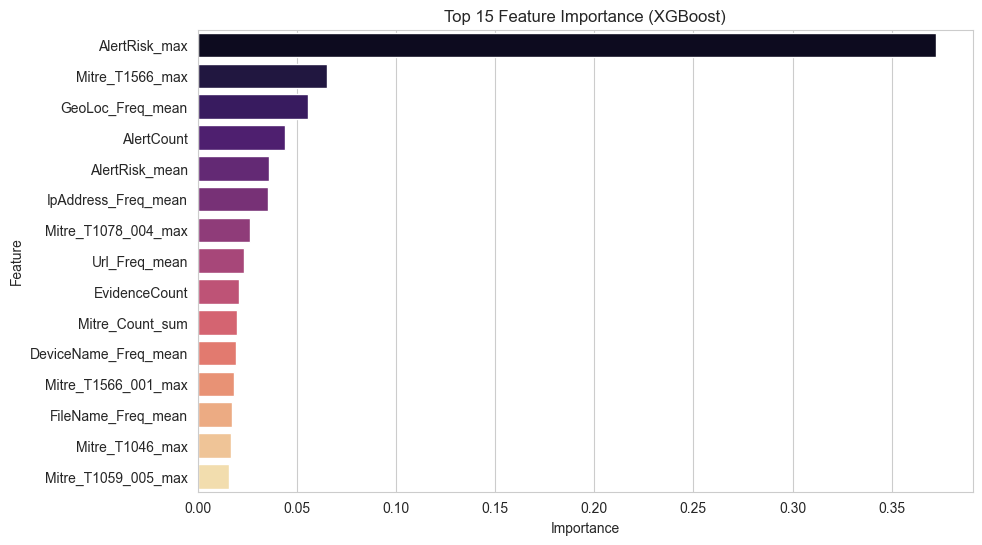

In [13]:
importance = models['XGBoost'].feature_importances_
feat_names = X_train.columns

feat_imp = pd.DataFrame({'Feature': feat_names, 'Importance': importance})
feat_imp = feat_imp.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='magma')
plt.title('Top 15 Feature Importance (XGBoost)')
plt.show()

## 7. MLP con PyTorch (con Early Stopping)

Implementiamo una rete neurale più sofisticata con PyTorch, includendo:
- **Validation monitoring** ad ogni epoca
- **Early stopping** basato sulla validation loss (patience=10)
- **Salvataggio del best model**

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
import copy

# 1. Rilevamento Hardware (GPU/MPS/CPU)
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"🎮 Utilizzo GPU NVIDIA: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print("🍎 Utilizzo Accelerazione Apple Silicon (MPS)")
else:
    device = torch.device('cpu')
    print("💻 GPU non rilevata, utilizzo CPU")

# 2. Definizione dell'Architettura della Rete (MLP)
class IncidentMLP(nn.Module):
    def __init__(self, input_dim):
        super(IncidentMLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.layers(x)

# 3. Preparazione dei Dati
X_train_t = torch.FloatTensor(X_train_scaled).to(device)
y_train_t = torch.FloatTensor(y_train.values).view(-1, 1).to(device)

X_val_t = torch.FloatTensor(X_val_scaled).to(device)
y_val_t = torch.FloatTensor(y_val.values).view(-1, 1).to(device)

X_test_t = torch.FloatTensor(X_test_scaled).to(device)
y_test_t = torch.FloatTensor(y_test_final.values).view(-1, 1).to(device)

# DataLoaders
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=512, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=512, shuffle=False)

# 4. Inizializzazione Modello
model_pt = IncidentMLP(X_train_t.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_pt.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

# 5. Training Loop con Early Stopping
epochs = 100
patience = 10
best_val_loss = float('inf')
best_model_state = None
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'val_f1': []}

print("\n--- Inizio Addestramento PyTorch con Early Stopping ---")
for epoch in range(epochs):
    # Training phase
    model_pt.train()
    train_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model_pt(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    
    # Validation phase
    model_pt.eval()
    val_loss = 0.0
    val_preds = []
    val_probs = []
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = model_pt(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
            probs = torch.sigmoid(outputs).cpu().numpy().flatten()
            val_probs.extend(probs)
            val_preds.extend((probs > 0.5).astype(int))
    val_loss /= len(val_loader)
    val_f1 = f1_score(y_val, val_preds)
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)
    
    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model_pt.state_dict())
        patience_counter = 0
        if (epoch + 1) % 5 == 0:
            print(f"Epoca [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val F1: {val_f1:.4f} ✓ (best)")
    else:
        patience_counter += 1
        if (epoch + 1) % 5 == 0:
            print(f"Epoca [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val F1: {val_f1:.4f}")
        
        if patience_counter >= patience:
            print(f"\n⚠️ Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
            break

# Carica il best model
model_pt.load_state_dict(best_model_state)
print(f"\n✅ Best model restored (Val Loss: {best_val_loss:.4f})")

# 6. Valutazione sul Hold-out Set (GUIDE_Test)
model_pt.eval()
with torch.no_grad():
    logits = model_pt(X_test_t)
    probs_pt = torch.sigmoid(logits).cpu().numpy().flatten()
    preds_pt = (probs_pt > 0.5).astype(int)

# 7. Risultati Finali
f1 = f1_score(y_test_final, preds_pt)
auc = roc_auc_score(y_test_final, probs_pt)
acc = accuracy_score(y_test_final, preds_pt)

print("\n" + "="*40)
print("RISULTATI FINALI PYTORCH (con Early Stopping)")
print("="*40)
print(f"Accuracy:  {acc:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC AUC:   {auc:.4f}")

🎮 Utilizzo GPU NVIDIA: NVIDIA GeForce RTX 3060 Ti

--- Inizio Addestramento PyTorch con Early Stopping ---
Epoca [5/100] - Train Loss: 0.3751, Val Loss: 0.3948, Val F1: 0.8066 ✓ (best)
Epoca [10/100] - Train Loss: 0.3679, Val Loss: 0.3937, Val F1: 0.8078
Epoca [15/100] - Train Loss: 0.3643, Val Loss: 0.3913, Val F1: 0.8082
Epoca [20/100] - Train Loss: 0.3622, Val Loss: 0.3882, Val F1: 0.8092
Epoca [25/100] - Train Loss: 0.3603, Val Loss: 0.3902, Val F1: 0.8110
Epoca [30/100] - Train Loss: 0.3588, Val Loss: 0.3885, Val F1: 0.8118
Epoca [35/100] - Train Loss: 0.3582, Val Loss: 0.3864, Val F1: 0.8112
Epoca [40/100] - Train Loss: 0.3573, Val Loss: 0.3881, Val F1: 0.8134
Epoca [45/100] - Train Loss: 0.3569, Val Loss: 0.3854, Val F1: 0.8125
Epoca [50/100] - Train Loss: 0.3539, Val Loss: 0.3844, Val F1: 0.8133
Epoca [55/100] - Train Loss: 0.3527, Val Loss: 0.3831, Val F1: 0.8145
Epoca [60/100] - Train Loss: 0.3521, Val Loss: 0.3811, Val F1: 0.8138 ✓ (best)
Epoca [65/100] - Train Loss: 0.3514,

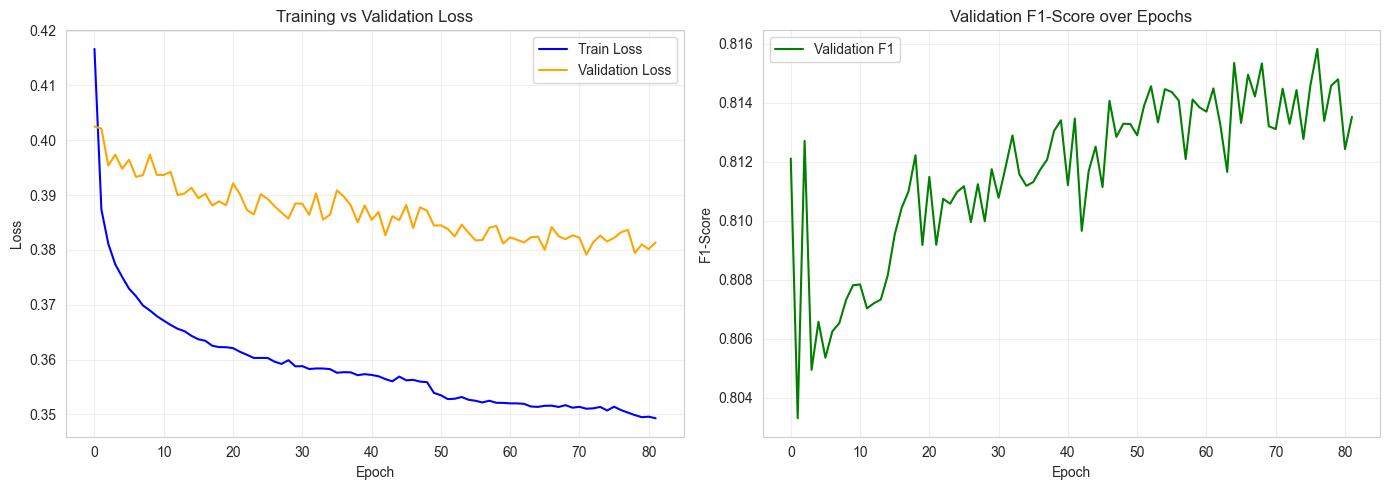

Training terminato all'epoca 82
Best Validation F1: 0.8158


In [15]:
# Learning Curves del MLP
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(history['train_loss'], label='Train Loss', color='blue')
axes[0].plot(history['val_loss'], label='Validation Loss', color='orange')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F1 curve
axes[1].plot(history['val_f1'], label='Validation F1', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1-Score')
axes[1].set_title('Validation F1-Score over Epochs')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Training terminato all'epoca {len(history['train_loss'])}")
print(f"Best Validation F1: {max(history['val_f1']):.4f}")

## 8. Salvataggio Modelli e Risultati

In [16]:
import json
import joblib

# Directory per salvare i modelli
MODELS_DIR = '../models'
os.makedirs(MODELS_DIR, exist_ok=True)

# Salva iperparametri ottimali e risultati CV
cv_results = {
    'DecisionTree': {
        'best_params': dt_search.best_params_,
        'cv_f1_mean': dt_search.best_score_,
        'cv_f1_std': dt_search.cv_results_['std_test_score'][dt_search.best_index_]
    },
    'RandomForest': {
        'best_params': rf_search.best_params_,
        'cv_f1_mean': rf_search.best_score_,
        'cv_f1_std': rf_search.cv_results_['std_test_score'][rf_search.best_index_]
    },
    'XGBoost': {
        'best_params': xgb_search.best_params_,
        'cv_f1_mean': xgb_search.best_score_,
        'cv_f1_std': xgb_search.cv_results_['std_test_score'][xgb_search.best_index_]
    }
}

# Salva CV results
with open(os.path.join(MODELS_DIR, 'cv_results.json'), 'w') as f:
    json.dump(cv_results, f, indent=2, default=str)

# Salva modelli sklearn
for name, model in models.items():
    model_path = os.path.join(MODELS_DIR, f'{name.lower()}_model.pkl')
    joblib.dump(model, model_path)
    print(f"✅ {name} salvato in {model_path}")

# Salva modello PyTorch
torch.save({
    'model_state_dict': model_pt.state_dict(),
    'input_dim': X_train_t.shape[1],
    'history': history
}, os.path.join(MODELS_DIR, 'mlp_pytorch_model.pth'))
print(f"✅ MLP PyTorch salvato in {os.path.join(MODELS_DIR, 'mlp_pytorch_model.pth')}")

# Salva metriche finali
final_results = {
    'test_metrics': metrics_df.to_dict(),
    'cv_results': cv_results,
    'pytorch_metrics': {
        'accuracy': float(acc),
        'f1_score': float(f1),
        'roc_auc': float(auc)
    }
}

with open(os.path.join(MODELS_DIR, 'final_results.json'), 'w') as f:
    json.dump(final_results, f, indent=2, default=str)

print(f"\n✅ Tutti i risultati salvati in {MODELS_DIR}/")
print("   - cv_results.json (iperparametri e CV scores)")
print("   - *_model.pkl (modelli sklearn)")
print("   - mlp_pytorch_model.pth (modello PyTorch)")
print("   - final_results.json (metriche finali)")

✅ DecisionTree salvato in ../models\decisiontree_model.pkl
✅ RandomForest salvato in ../models\randomforest_model.pkl
✅ XGBoost salvato in ../models\xgboost_model.pkl
✅ MLP salvato in ../models\mlp_model.pkl
✅ MLP PyTorch salvato in ../models\mlp_pytorch_model.pth

✅ Tutti i risultati salvati in ../models/
   - cv_results.json (iperparametri e CV scores)
   - *_model.pkl (modelli sklearn)
   - mlp_pytorch_model.pth (modello PyTorch)
   - final_results.json (metriche finali)
